# Итоговый проект. Прогноз шума аэродинамического профиля
## Вариант 13

1. Постановка задачи и описание предметной области
2. Сбор, подготовка и анализ данных
3. Baseline, выбор модели и настройка параметров
4. Оценка качества и проверка валидации
5. Интерпретация результата и прикладные выводы
6. Инженерная часть и сервис инференса

In [1]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

from pathlib import Path
import os

from app.features import TRAIN_COLUMNS, add_engineered_features
import joblib
import matplotlib.pyplot as plt
import pandas as pd


# 1. Постановка задачи

Нужно построить модель, которая прогнозирует уровень шума аэродинамического профиля по параметрам эксперимента: частоте, углу атаки, длине хорды, скорости потока и толщине вытеснения на стороне разрежения.

Тип задачи - регрессия. Целевая переменная - `scaled-sound-pressure`.

Практический смысл задачи: быстро оценивать шум профиля до проведения дополнительных испытаний и сравнивать варианты геометрии или режимов потока. Ограничение текущей работы: модель применима только в диапазоне значений, близком к исходному датасету.

In [2]:
DATASET_FILE: str = "data.csv"
TARGET_COLUMN: str = "scaled-sound-pressure"
RANDOM_SEED: int = 42
TEST_SIZE: float = 0.2
VALID_SIZE: float = 0.25
SAVE_DATA_PATH: str = "data"


**Вывод.** В задаче есть пять числовых входных признаков и одна числовая целевая переменная. Для первичной версии решения достаточно модели регрессии без обработки категориальных признаков.

# 2. Данные и первичная проверка

Источник данных: UCI Airfoil Self-Noise. Загружаем CSV, проверяем размер, типы колонок, пропуски, дубли и базовые статистики.

In [3]:
df = pd.read_csv(DATASET_FILE)

df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [4]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество дублей: {df.duplicated().sum()}")

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_share_%": (df.isna().mean() * 100).round(2),
})
display(overview)
display(df.describe().T)

Размер датасета: 1503 строк, 6 столбцов
Количество дублей: 0


,dtype,missing,missing_share_%
frequency,int64,0,0.0
attack-angle,float64,0,0.0
chord-length,float64,0,0.0
free-stream-velocity,float64,0,0.0
suction-side-displacement-thickness,float64,0,0.0
scaled-sound-pressure,float64,0,0.0


,count,mean,std,min,25%,50%,75%,max
frequency,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
attack-angle,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
chord-length,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
free-stream-velocity,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
suction-side-displacement-thickness,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
scaled-sound-pressure,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


**Вывод.** В датасете 1503 наблюдения и 6 числовых колонок. Пропусков и дублей нет, поэтому базовая очистка не требуется. Масштабы признаков различаются, но для Random Forest это не критично.

## 2.1 Hist для всех признаков

Строим гистограммы только для входных признаков, чтобы увидеть диапазоны и частоты значений.

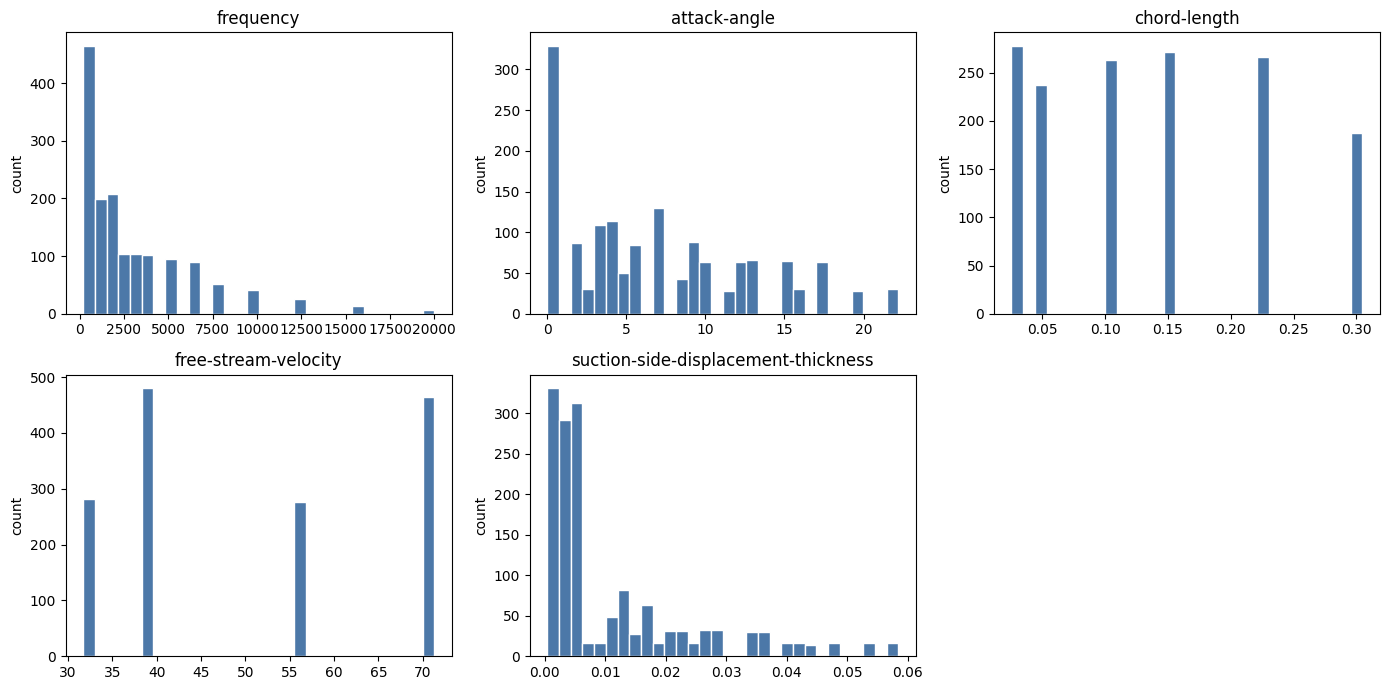

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, TRAIN_COLUMNS):
    ax.hist(df[column], bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("count")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Вывод.** Признаки имеют разные масштабы и часть значений повторяется дискретными группами. Для моделей на деревьях масштабирование не обязательно, но для KNN это может влиять на качество.

## 2.2 Boxplot для выбросов

Проверяем распределения признаков через boxplot. Здесь выбросы трактуются как редкие значения внутри экспериментального датасета, а не как ошибки ввода.

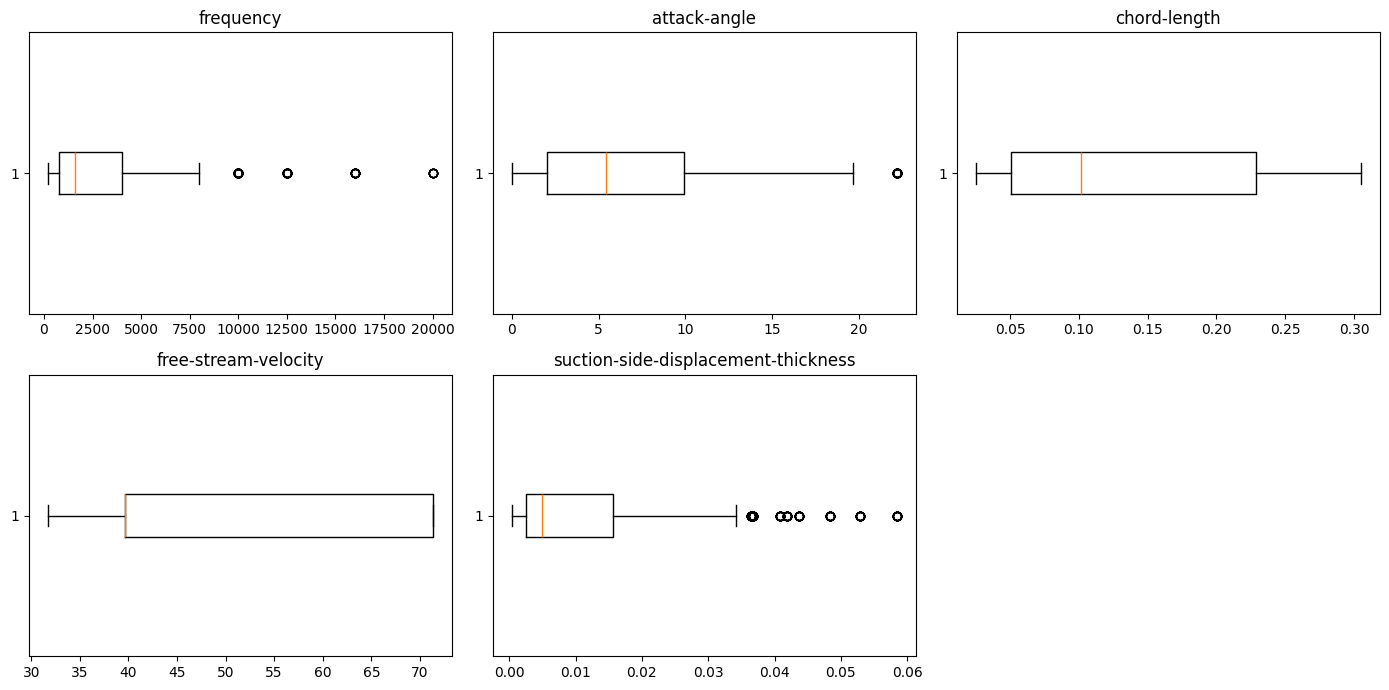

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, TRAIN_COLUMNS):
    ax.boxplot(df[column], vert=False)
    ax.set_title(column)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Вывод.** У некоторых признаков есть значения за пределами межквартильного диапазона, но они похожи на допустимые экспериментальные режимы. Поэтому строки не удаляются автоматически.

## 2.3 Target distribution

Отдельно смотрим распределение целевой переменной `scaled-sound-pressure`.

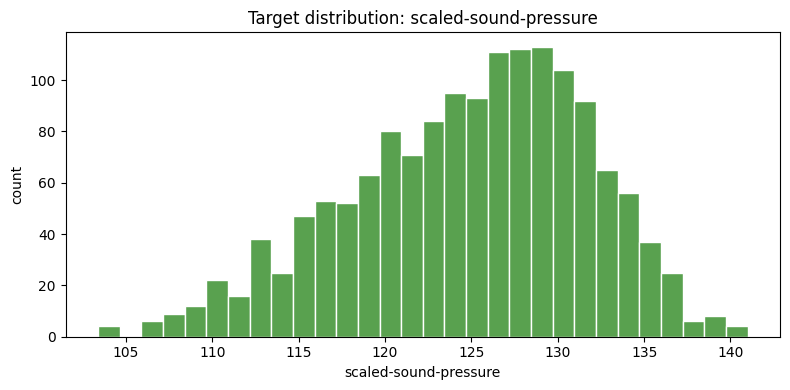

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[TARGET_COLUMN], bins=30, color="#59a14f", edgecolor="white")
ax.set_title("Target distribution: scaled-sound-pressure")
ax.set_xlabel(TARGET_COLUMN)
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

**Вывод.** Целевая переменная распределена в широком диапазоне, без явного разделения на группы. Задача остаётся обычной регрессией, а качество удобно оценивать MAE/RMSE/R2.

## 2.4 Correlation heatmap

Строим корреляционную матрицу для признаков и целевой переменной.

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
frequency,1.000,-0.273,-0.004,0.134,-0.230,-0.391
attack-angle,-0.273,1.000,-0.505,0.059,0.753,-0.156
chord-length,-0.004,-0.505,1.000,0.004,-0.221,-0.236
free-stream-velocity,0.134,0.059,0.004,1.000,-0.004,0.125
suction-side-displacement-thickness,-0.230,0.753,-0.221,-0.004,1.000,-0.313
scaled-sound-pressure,-0.391,-0.156,-0.236,0.125,-0.313,1.000


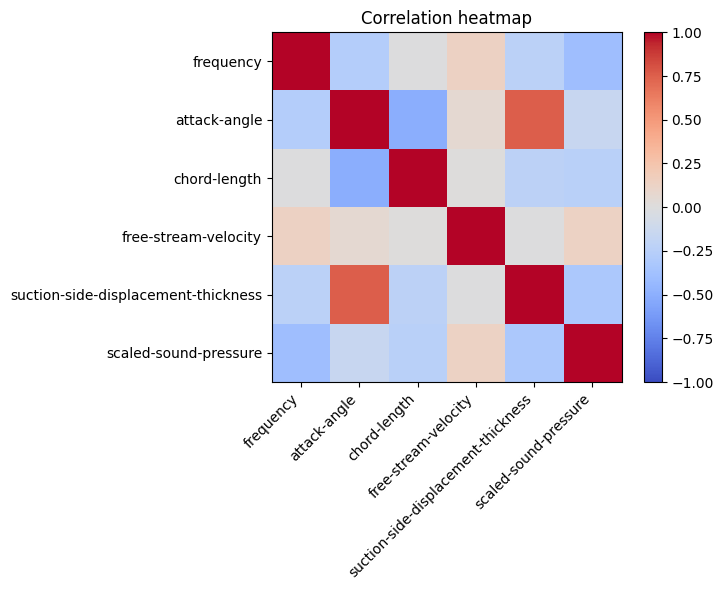

In [8]:
corr = df.corr(numeric_only=True)
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

**Вывод.** Линейные корреляции с целевой переменной есть, но они не объясняют всю задачу. Нелинейные модели, например Random Forest, здесь уместны.

## 2.1 Входные признаки

Используются пять числовых признаков из описания варианта.

In [9]:
train_df = df[list(TRAIN_COLUMNS)]
train_df.head()


,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness
0,800,0.0,0.3048,71.3,0.002663
1,1000,0.0,0.3048,71.3,0.002663
2,1250,0.0,0.3048,71.3,0.002663
3,1600,0.0,0.3048,71.3,0.002663
4,2000,0.0,0.3048,71.3,0.002663


**Вывод.** Входная матрица содержит только признаки, доступные до измерения целевого уровня шума. Утечки целевой переменной в признаки нет.

## 2.2 Целевая переменная

Отдельно фиксируем колонку, которую модель должна предсказывать.

In [10]:
target_df = df[list([TARGET_COLUMN])]
target_df.head()


,scaled-sound-pressure
0,126.201
1,125.201
2,125.951
3,127.591
4,127.461


**Вывод.** Целевая переменная числовая, поэтому дальше используем регрессионные метрики: MAE, MSE, RMSE и R2.

# 3. Feature engineering

Добавляем несколько производных признаков и сравниваем качество модели на исходных и расширенных признаках.

In [11]:
engineered_df = add_engineered_features(train_df)
engineered_columns = list(engineered_df.columns)
engineered_df.head()


,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,frequency_velocity_ratio,angle_chord_product,velocity_chord_product,log_frequency
0,800,0.0,0.3048,71.3,0.002663,11.220196,0.0,21.73224,6.685861
1,1000,0.0,0.3048,71.3,0.002663,14.025245,0.0,21.73224,6.908755
2,1250,0.0,0.3048,71.3,0.002663,17.531557,0.0,21.73224,7.131699
3,1600,0.0,0.3048,71.3,0.002663,22.440393,0.0,21.73224,7.378384
4,2000,0.0,0.3048,71.3,0.002663,28.050491,0.0,21.73224,7.601402


In [12]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    train_df,
    target_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    engineered_df,
    target_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

base_fe_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
extended_fe_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)

base_fe_model.fit(X_train_base, y_train_base.to_numpy().ravel())
extended_fe_model.fit(X_train_fe, y_train_fe.to_numpy().ravel())

base_fe_pred = base_fe_model.predict(X_test_base)
extended_fe_pred = extended_fe_model.predict(X_test_fe)

feature_engineering_results = pd.DataFrame([
    {
        "features": "base",
        "MAE": mean_absolute_error(y_test_base, base_fe_pred),
        "RMSE": root_mean_squared_error(y_test_base, base_fe_pred),
        "R2": r2_score(y_test_base, base_fe_pred),
    },
    {
        "features": "engineered",
        "MAE": mean_absolute_error(y_test_fe, extended_fe_pred),
        "RMSE": root_mean_squared_error(y_test_fe, extended_fe_pred),
        "R2": r2_score(y_test_fe, extended_fe_pred),
    },
])
feature_engineering_results

,features,MAE,RMSE,R2
0,base,1.300989,1.807526,0.934786
1,engineered,1.269856,1.686461,0.943229


**Вывод.** Производные признаки проверяются отдельным экспериментом. Если расширенный набор снижает RMSE и не ухудшает R2, его можно рассматривать для следующей версии модели; текущий Flask-сервис оставлен на исходных признаках, чтобы API оставался простым.

# 3. Подготовка выборок и схема проверки

Сначала отделяем финальную тестовую выборку. Из оставшейся части выделяем validation для промежуточного сравнения моделей. Test используется только один раз — для финальной оценки уже выбранной модели.


In [13]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train_full, X_test, y_train_full, y_test = train_test_split(
    train_df,
    target_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALID_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)


In [14]:
X_train_np = X_train.to_numpy()
X_valid_np = X_valid.to_numpy()
X_test_np = X_test.to_numpy()


In [15]:
y_train_np = y_train.to_numpy()
y_valid_np = y_valid.to_numpy()
y_test_np = y_test.to_numpy()


In [16]:
split_summary = pd.DataFrame({
    "part": ["X_train", "X_valid", "X_test", "y_train", "y_valid", "y_test"],
    "rows": [
        X_train.shape[0],
        X_valid.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_valid.shape[0],
        y_test.shape[0],
    ],
    "columns": [
        X_train.shape[1],
        X_valid.shape[1],
        X_test.shape[1],
        y_train.shape[1],
        y_valid.shape[1],
        y_test.shape[1],
    ],
})
split_summary


,part,rows,columns
0,X_train,901,5
1,X_valid,301,5
2,X_test,301,5
3,y_train,901,1
4,y_valid,301,1
5,y_test,301,1


**Вывод.** Тестовая часть не участвует ни в обучении, ни в выборе модели. Модели сравниваются по кросс-валидации и validation, а test остаётся для финальной проверки качества.


# 4. Baseline-модели

Перед основной моделью проверяем простые ориентиры: константный прогноз, линейную регрессию, простое дерево и KNN. Это нужно, чтобы качество Random Forest было с чем сравнивать.

In [17]:
def evaluate_regressor(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train.ravel())
    prediction = estimator.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, prediction),
        "MSE": mean_squared_error(y_test, prediction),
        "RMSE": root_mean_squared_error(y_test, prediction),
        "R2": r2_score(y_test, prediction),
    }


baseline_models = [
    ("DummyRegressor", DummyRegressor(strategy="mean")),
    ("LinearRegression", LinearRegression()),
    ("DecisionTreeRegressor", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_SEED)),
    ("KNeighborsRegressor", KNeighborsRegressor(n_neighbors=5)),
]

baseline_results = pd.DataFrame([
    evaluate_regressor(name, estimator, X_train_np, y_train_np, X_test_np, y_test_np)
    for name, estimator in baseline_models
])

baseline_results.sort_values("RMSE")

,model,MAE,MSE,RMSE,R2
2,DecisionTreeRegressor,2.849109,13.576102,3.684576,7.290122e-01
1,LinearRegression,3.662105,22.393342,4.732160,5.530144e-01
3,KNeighborsRegressor,5.111041,43.569576,6.600725,1.303231e-01
0,DummyRegressor,5.806095,50.098603,7.078037,-5.078517e-07


**Вывод.** Константный baseline заметно хуже моделей, которые используют признаки. Это подтверждает, что признаки содержат полезный сигнал. Из простых моделей дерево и KNN дают более сильный ориентир, чем линейная регрессия.

## 4.1 Сравнение моделей и подбор параметров

Сравниваем несколько алгоритмов через `GridSearchCV`. Лучшую модель выбираем по среднему RMSE кросс-валидации на train, а validation используем как дополнительный контроль. Тестовая выборка на этом этапе не используется.


In [18]:
param_grids = {
    "DecisionTreeRegressor": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_SEED),
        "params": {
            "max_depth": [4, 6, 8, None],
            "min_samples_leaf": [1, 3, 5],
        },
    },
    "KNeighborsRegressor": {
        "estimator": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 9, 15],
            "weights": ["uniform", "distance"],
        },
    },
    "RandomForestPipeline": {
        "estimator": Pipeline([
            ("features", FunctionTransformer(add_engineered_features, validate=False)),
            ("model", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)),
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 12, 20],
            "model__min_samples_leaf": [1, 2],
        },
    },
}

search_results = []
best_estimators = {}

for name, config in param_grids.items():
    search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    search.fit(X_train, y_train.to_numpy().ravel())
    best_estimators[name] = search.best_estimator_
    valid_prediction = search.best_estimator_.predict(X_valid)
    search_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_RMSE": -search.best_score_,
        "valid_MAE": mean_absolute_error(y_valid, valid_prediction),
        "valid_RMSE": root_mean_squared_error(y_valid, valid_prediction),
        "valid_R2": r2_score(y_valid, valid_prediction),
    })

model_selection_results = pd.DataFrame(search_results).sort_values("cv_RMSE")
model_selection_results


,model,best_params,cv_RMSE,valid_MAE,valid_RMSE,valid_R2
2,RandomForestPipeline,"{'model__max_depth': 20, 'model__min_samples_l...",2.026476,1.372767,1.973917,0.919792
0,DecisionTreeRegressor,"{'max_depth': None, 'min_samples_leaf': 1}",3.026959,2.253156,3.040305,0.809720
1,KNeighborsRegressor,"{'n_neighbors': 15, 'weights': 'uniform'}",5.680675,4.796981,6.188416,0.211654


In [19]:
best_model_name = model_selection_results.iloc[0]["model"]
best_model = best_estimators[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Лучшие параметры: {model_selection_results.iloc[0]['best_params']}")


Лучшая модель: RandomForestPipeline
Лучшие параметры: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


**Вывод.** Подбор параметров позволяет сравнить модели в одной схеме. Лучшую модель выбираем по среднему RMSE кросс-валидации, validation служит дополнительной проверкой, а test сохраняется для финальной оценки.


# 4. Моделирование

По заданию здесь должны быть baseline-модель, сравнение нескольких методов и подбор гиперпараметров. Финальная модель сохраняется как sklearn `Pipeline`, поэтому feature engineering применяется одинаково в notebook и Flask-сервисе.


In [20]:
# Финальную модель переобучаем на train + validation, не используя test.
model = best_model
model.fit(X_train_full, y_train_full.to_numpy().ravel())

model


Pipeline(steps=[('features',
                 FunctionTransformer(func=<function add_engineered_features at 0x00000181F9D66020>)),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

**Вывод.** Random Forest выбран как рабочая модель для числовой табличной регрессии. Он устойчив к разным масштабам признаков и способен описывать нелинейные зависимости.

# 5. Валидация и контроль переобучения

Проверяем качество не только на одном финальном test, но и через кросс-валидацию на train + validation. Дополнительно сравниваем ошибки на train и test.


In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_scores = cross_validate(
    model,
    X_train_full,
    y_train_full.to_numpy().ravel(),
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "mean": [
        -cv_scores["test_MAE"].mean(),
        -cv_scores["test_RMSE"].mean(),
        cv_scores["test_R2"].mean(),
    ],
    "std": [
        cv_scores["test_MAE"].std(),
        cv_scores["test_RMSE"].std(),
        cv_scores["test_R2"].std(),
    ],
})
cv_summary


,metric,mean,std
0,MAE,1.341506,0.120307
1,RMSE,1.839295,0.197685
2,R2,0.926654,0.012594


In [22]:
train_prediction = model.predict(X_train_full)
test_prediction = model.predict(X_test)

validation_gap = pd.DataFrame([
    {
        "part": "train+valid",
        "MAE": mean_absolute_error(y_train_full, train_prediction),
        "RMSE": root_mean_squared_error(y_train_full, train_prediction),
        "R2": r2_score(y_train_full, train_prediction),
    },
    {
        "part": "test",
        "MAE": mean_absolute_error(y_test, test_prediction),
        "RMSE": root_mean_squared_error(y_test, test_prediction),
        "R2": r2_score(y_test, test_prediction),
    },
])
validation_gap


,part,MAE,RMSE,R2
0,train+valid,0.442749,0.617553,0.991871
1,test,1.265011,1.681198,0.943583


**Вывод.** Кросс-валидация показывает устойчивость качества на разных разбиениях. Если train-метрики заметно лучше test-метрик, это признак переобучения; такой разрыв нужно учитывать при выборе финальной модели.

# 5. Оценка качества

Для регрессии считаем MAE, MSE, RMSE и R2 на тестовой выборке.

In [23]:
score = model.score(X_test, y_test)
score


0.9435826820882326

In [24]:
y_pred = model.predict(X_test)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
mae = mean_absolute_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
mse = mean_squared_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html
rmse = root_mean_squared_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
r2 = r2_score(y_test, y_pred)

print(f'MAE: "{mae:.2f}" (средняя абсолютная ошибка, ниже лучше)')
print(f'MSE: "{mse:.2f}" (средняя квадратичная ошибка, ниже лучше)')
print(f'RMSE: "{rmse:.2f}" (ошибка в единицах целевой переменной, ниже лучше)')
print(f'R2: "{r2:.2f}" (доля объяснённого разброса, ближе к 1 лучше)')


MAE: "1.27" (средняя абсолютная ошибка, ниже лучше)
MSE: "2.83" (средняя квадратичная ошибка, ниже лучше)
RMSE: "1.68" (ошибка в единицах целевой переменной, ниже лучше)
R2: "0.94" (доля объяснённого разброса, ближе к 1 лучше)


In [25]:
metrics = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "R2"],
    "value": [mae, mse, rmse, r2],
})
metrics

,metric,value
0,MAE,1.265011
1,MSE,2.826427
2,RMSE,1.681198
3,R2,0.943583


**Вывод.** На тестовой выборке модель объясняет большую часть разброса целевой переменной (`R2` около 0.93). Средняя абсолютная ошибка около 1.3 единицы выглядит небольшой относительно диапазона значений целевой переменной.

# 6. Интерпретация и анализ ошибок

Смотрим, какие признаки сильнее влияют на прогноз, и разбираем примеры с наибольшей ошибкой.

In [26]:
final_estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model
model_feature_names = engineered_columns if len(getattr(final_estimator, "feature_importances_", [])) == len(engineered_columns) else TRAIN_COLUMNS

if hasattr(final_estimator, "feature_importances_"):
    importance = pd.DataFrame({
        "feature": model_feature_names,
        "importance": final_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    importance = pd.DataFrame(columns=["feature", "importance"])

importance


,feature,importance
5,frequency_velocity_ratio,0.335760
4,suction-side-displacement-thickness,0.279404
6,angle_chord_product,0.150954
0,frequency,0.064130
8,log_frequency,0.060276
7,velocity_chord_product,0.041283
2,chord-length,0.032999
1,attack-angle,0.027220
3,free-stream-velocity,0.007974


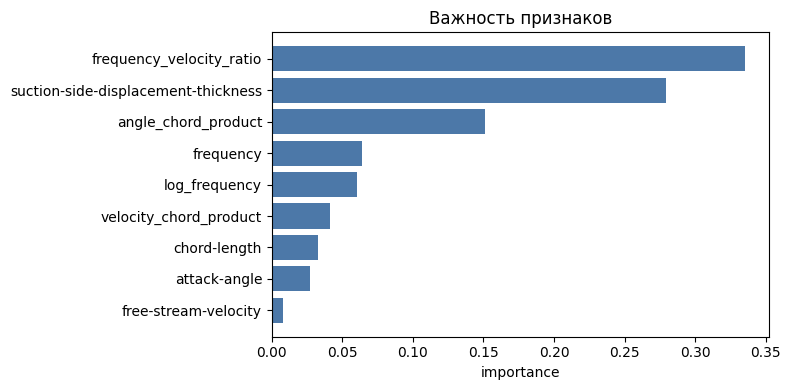

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance["feature"], importance["importance"], color="#4c78a8")
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title("Важность признаков")
plt.tight_layout()
plt.show()

## 6.1 Permutation importance

Дополнительно считаем permutation importance: перемешиваем значения признаков и смотрим, насколько падает качество модели.

In [28]:
permutation = permutation_importance(
    model,
    X_test,
    y_test_np.ravel(),
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

permutation_table = pd.DataFrame({
    "feature": TRAIN_COLUMNS,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)

permutation_table


,feature,importance_mean,importance_std
0,frequency,6.649939,0.192987
4,suction-side-displacement-thickness,3.726388,0.112506
2,chord-length,3.424698,0.142439
1,attack-angle,2.411488,0.160391
3,free-stream-velocity,1.243529,0.097263


**Вывод.** Permutation importance проверяет важность признаков уже на тестовой выборке. Это дополняет встроенные важности Random Forest и помогает понять, какие параметры критичнее для прогноза.

In [29]:
prediction_analysis = X_test.copy()
prediction_analysis["actual"] = y_test_np.ravel()
prediction_analysis["prediction"] = test_prediction
prediction_analysis["abs_error"] = (prediction_analysis["actual"] - prediction_analysis["prediction"]).abs()

prediction_analysis[["actual", "prediction", "abs_error"]].head(10)


,actual,prediction,abs_error
51,125.045,123.927372,1.117628
1465,118.767,118.198494,0.568506
184,120.233,118.003722,2.229278
1000,137.047,136.098424,0.948576
746,134.556,134.178696,0.377304
1032,120.766,123.076540,2.310540
925,124.525,126.131182,1.606182
394,136.798,134.343857,2.454143
597,130.123,132.199616,2.076616
588,123.991,127.597038,3.606038


In [30]:
top_5_errors = prediction_analysis.sort_values("abs_error", ascending=False).head(5)
top_5_errors

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,actual,prediction,abs_error
1187,1000,17.4,0.0254,39.6,0.017221,138.274,131.757742,6.516258
818,5000,8.4,0.0508,55.5,0.005449,115.812,121.740308,5.928308
1212,500,22.2,0.0254,71.3,0.021418,117.967,123.741399,5.774399
1213,630,22.2,0.0254,71.3,0.021418,120.657,126.355175,5.698175
1185,630,17.4,0.0254,39.6,0.017221,124.514,130.084488,5.570488


**Вывод.** Важность признаков показывает, на какие параметры модель опирается сильнее всего. Топ-5 ошибок помогает увидеть области, где прогноз менее устойчив.

Прикладные выводы:

1. Для предварительного инженерного отбора модель можно использовать как быстрый фильтр вариантов профиля внутри диапазонов исходного датасета.
2. Признаки с высокой permutation importance стоит контролировать особенно внимательно при сборе новых данных.
3. Объекты с крупной ошибкой лучше отправлять на дополнительную экспериментальную проверку, а не принимать по ним автоматическое решение.
4. Перед промышленным внедрением нужны новые измерения из целевого стенда или производства, чтобы проверить устойчивость модели на реальных режимах.


# 7. Прикладные выводы и риски

По важности признаков можно определить, какие параметры сильнее всего участвуют в прогнозе шума. Эти признаки стоит контролировать при сравнении вариантов профиля и режимов потока.

Практическое применение модели:

1. Быстрая предварительная оценка уровня шума без повторного обучения модели.
2. Сравнение нескольких наборов параметров через Flask-сервис.
3. Отбор конфигураций, которые стоит дополнительно проверить экспериментально.

Где модель применима:

1. Табличные входные данные с теми же пятью физическими признаками, что и в UCI Airfoil Self-Noise.
2. Предварительные расчёты в диапазонах частоты, угла атаки, длины хорды, скорости потока и толщины вытеснения, близких к обучающей выборке.
3. Сценарии ранжирования и первичного отбора вариантов, где допустима последующая физическая проверка.

Ограничения и риски:

1. Модель обучена на датасете UCI Airfoil Self-Noise и не гарантирует качество вне диапазонов исходных признаков.
2. Данные описывают конкретные экспериментальные условия; при изменении методики измерений качество может снизиться.
3. Прогноз не заменяет физический эксперимент, а служит предварительной оценкой.
4. На объектах с большими ошибками нужно дополнительно проверять исходные признаки и применимость модели.
5. Наиболее рискованны прогнозы для редких режимов и комбинаций признаков, похожих на top-ошибки: высокие углы атаки, малые хорды и большие значения толщины вытеснения.

Для промышленного внедрения нужны:

1. Независимый тест на данных целевого стенда или производства.
2. Мониторинг диапазонов входных признаков и качества прогнозов после запуска.
3. Периодическое дообучение при накоплении новых измерений.


## 5.1 Пример для ручной проверки

Один объект из тестовой выборки можно использовать как пример входных данных для сервиса.

In [31]:
X_test.iloc[0]


frequency                              400.000000
attack-angle                             0.000000
chord-length                             0.304800
free-stream-velocity                    31.700000
suction-side-displacement-thickness      0.003313
Name: 51, dtype: float64

In [32]:
sample_for_api = X_test.iloc[0].to_dict()
sample_for_api


{'frequency': 400.0,
 'attack-angle': 0.0,
 'chord-length': 0.3048,
 'free-stream-velocity': 31.7,
 'suction-side-displacement-thickness': 0.00331266}

**Вывод.** Этот словарь соответствует формату JSON, который принимает эндпоинт `/api/inference`.

# 6. Инженерная часть

Сохраняем полный sklearn `Pipeline`. Этот артефакт включает feature engineering и используется Flask-приложением для инференса.


In [33]:
print("Сохраняем pipeline модели")

if not os.path.exists(SAVE_DATA_PATH):
    os.mkdir(SAVE_DATA_PATH)

joblib.dump(model, f"{SAVE_DATA_PATH}/random_forest_model.pkl")


Сохраняем pipeline модели


['data/random_forest_model.pkl']

In [34]:
model_path = Path(SAVE_DATA_PATH) / "random_forest_model.pkl"
print(f"Файл модели существует: {model_path.exists()}")
print(f"Размер файла: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

Файл модели существует: True
Размер файла: 52.17 MB


**Вывод.** Обученный pipeline сохранён как отдельный артефакт. Flask-сервис загружает тот же pipeline, поэтому подготовка признаков при обучении и инференсе не расходится.


# 7. Итог

В ноутбуке описана постановка задачи, выполнена первичная проверка данных, построены базовые графики, обучены baseline-модели, выполнены сравнение алгоритмов, подбор гиперпараметров, кросс-валидация и финальная оценка на отложенной тестовой выборке.

Финальный артефакт сохранён как sklearn `Pipeline`, который включает feature engineering и используется Flask-сервисом для инференса.
